# 02_feature_engineering.ipynb
### Feature Construction & Predictive Analysis
---

## 1. Feature Engineering Summary
*Transforming raw meteorological and air quality data into temporal, lag, and rolling features.*

In [ ]:
# 1. Print the total shape
print(f"Final Engineered Dataset Shape: {final_engineered_df.shape[0]} rows, {final_engineered_df.shape[1]} columns")
print("-" * 50)

# 2. List all features cleanly
print("Engineered Feature List:")
for i, col in enumerate(final_engineered_df.columns, 1):
    print(f"{i:02d}. {col}")

Final Engineered Dataset Shape: 29136 rows, 87 columns
--------------------------------------------------
Engineered Feature List:
01. city
02. timestamp
03. pm10
04. pm2_5
05. carbon_monoxide
06. nitrogen_dioxide
07. ozone
08. sulphur_dioxide
09. us_aqi
10. european_aqi
11. temperature
12. humidity
13. wind_speed
14. pressure
15. precipitation
16. cloudcover
17. pm25_log
18. hour_of_day
19. day_of_week
20. month_of_year
21. day_of_month
22. week_of_year
23. is_weekend
24. season
25. hour_sin
26. hour_cos
27. day_sin
28. day_cos
29. month_sin
30. month_cos
31. aqi_lag_1h
32. aqi_lag_6h
33. aqi_lag_24h
34. aqi_rolling_avg_6h
35. aqi_rolling_avg_24h
36. aqi_change_rate_24h
37. pm25_lag_1
38. pm25_lag_2
39. pm25_lag_3
40. pm25_lag_6
41. pm25_lag_12
42. pm25_lag_24
43. pm25_lag_48
44. pm10_lag_6
45. pm10_lag_24
46. pm_ratio
47. pm25_roll_mean_3
48. pm25_roll_mean_6
49. pm25_roll_mean_12
50. pm25_roll_mean_24
51. pm25_roll_std_6
52. pm25_roll_std_12
53. pm25_roll_std_24
54. pm25_roll_min_6


## 2. Feature Prioritization Analysis
*Identifying the top predictive drivers for 24-hour AQI forecasting.*

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Define Features and Target
# We drop the timestamp and targets, then fill NaNs for the model
X = final_engineered_df.drop(columns=['timestamp', 'target_24h', 'target_48h', 'target_72h', 'city'], errors='ignore')
X = X.select_dtypes(include=[np.number]).fillna(0)
y = final_engineered_df['target_24h'].fillna(0)

# 2. Train a fast Random Forest to extract importance
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

# 3. Create a clean DataFrame of importance scores
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Display the top 10
print("--- 🏆 TOP 10 MOST INFLUENTIAL FEATURES ---")
print(importance_df.head(10).to_string(index=False))

--- 🏆 TOP 10 MOST INFLUENTIAL FEATURES ---
                 Feature  Importance
                   pm2_5    0.271460
                pm25_log    0.259600
                   ozone    0.024526
         sulphur_dioxide    0.024453
temperature_roll_mean_24    0.022465
   humidity_roll_mean_24    0.021291
             pm25_lag_24    0.021158
        pm25_roll_min_24    0.020471
 wind_speed_roll_mean_24    0.019624
   pressure_roll_mean_24    0.014156


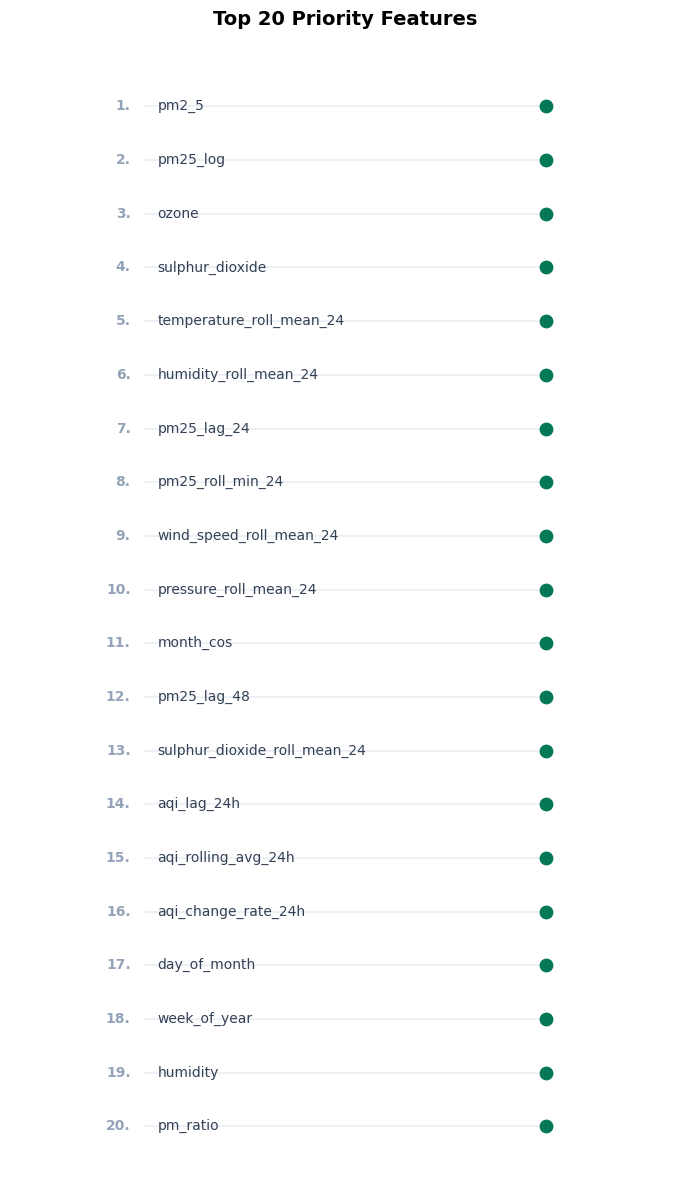

In [ ]:
import matplotlib.pyplot as plt

# Get the top 20
top_20 = importance_df.head(20).copy().reset_index(drop=True)

# Setup figure
plt.figure(figsize=(7, 12))

# Use dynamic range based on actual data length
y_positions = range(len(top_20), 0, -1)

# Lines and markers
plt.hlines(y=y_positions, xmin=0.2, xmax=0.8, color='#e2e8f0', linestyle='-', alpha=0.6)
plt.scatter([0.8]*len(top_20), y_positions, color='#047857', s=80, zorder=3)

# Labels
for i, row in top_20.iterrows():
    # Rank
    plt.text(0.18, y_positions[i], f"{i+1}.", va='center', ha='right',
             fontsize=10, fontweight='bold', color='#94a3b8')
    # Feature Name
    plt.text(0.22, y_positions[i], row['Feature'], va='center', ha='left',
             fontsize=10, fontweight='medium', color='#334155')

plt.title('Top 20 Priority Features', fontsize=14, fontweight='bold', pad=20)
plt.xlim(0, 1)
plt.ylim(0, 21) # Enough room for 20
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Multivariate Feature Comparison
*Analyzing the relationship between pollutants, meteorological trends, and the target variable.*

/tmp/ipykernel_1712/1074520719.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_weekend', y='target_24h', data=final_engineered_df, ax=axes[0], palette='viridis')


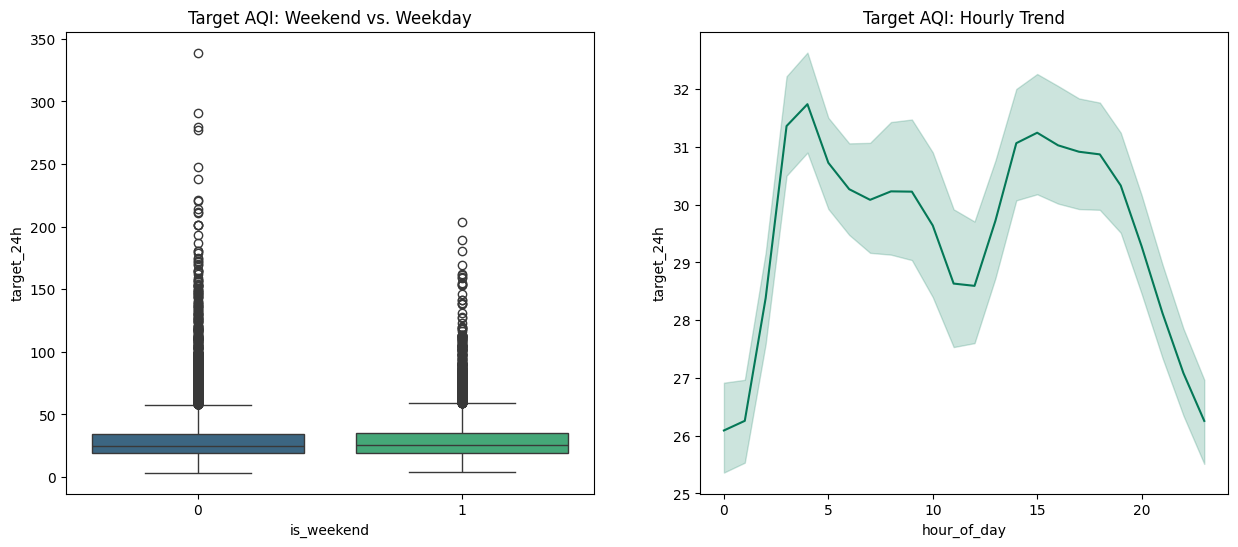

In [ ]:
# Create a grid to compare Categorical Time vs. Continuous Pollutant
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Weekend vs. Weekday impact
sns.boxplot(x='is_weekend', y='target_24h', data=final_engineered_df, ax=axes[0], palette='viridis')
axes[0].set_title('Target AQI: Weekend vs. Weekday')

# Hour of day impact
sns.lineplot(x='hour_of_day', y='target_24h', data=final_engineered_df, ax=axes[1], color='#047857')
axes[1].set_title('Target AQI: Hourly Trend')
plt.show()

## 4. Feature-Target Alignment
*Visualizing correlation matrix and pairwise relationships between key features and the 24-hour target.*

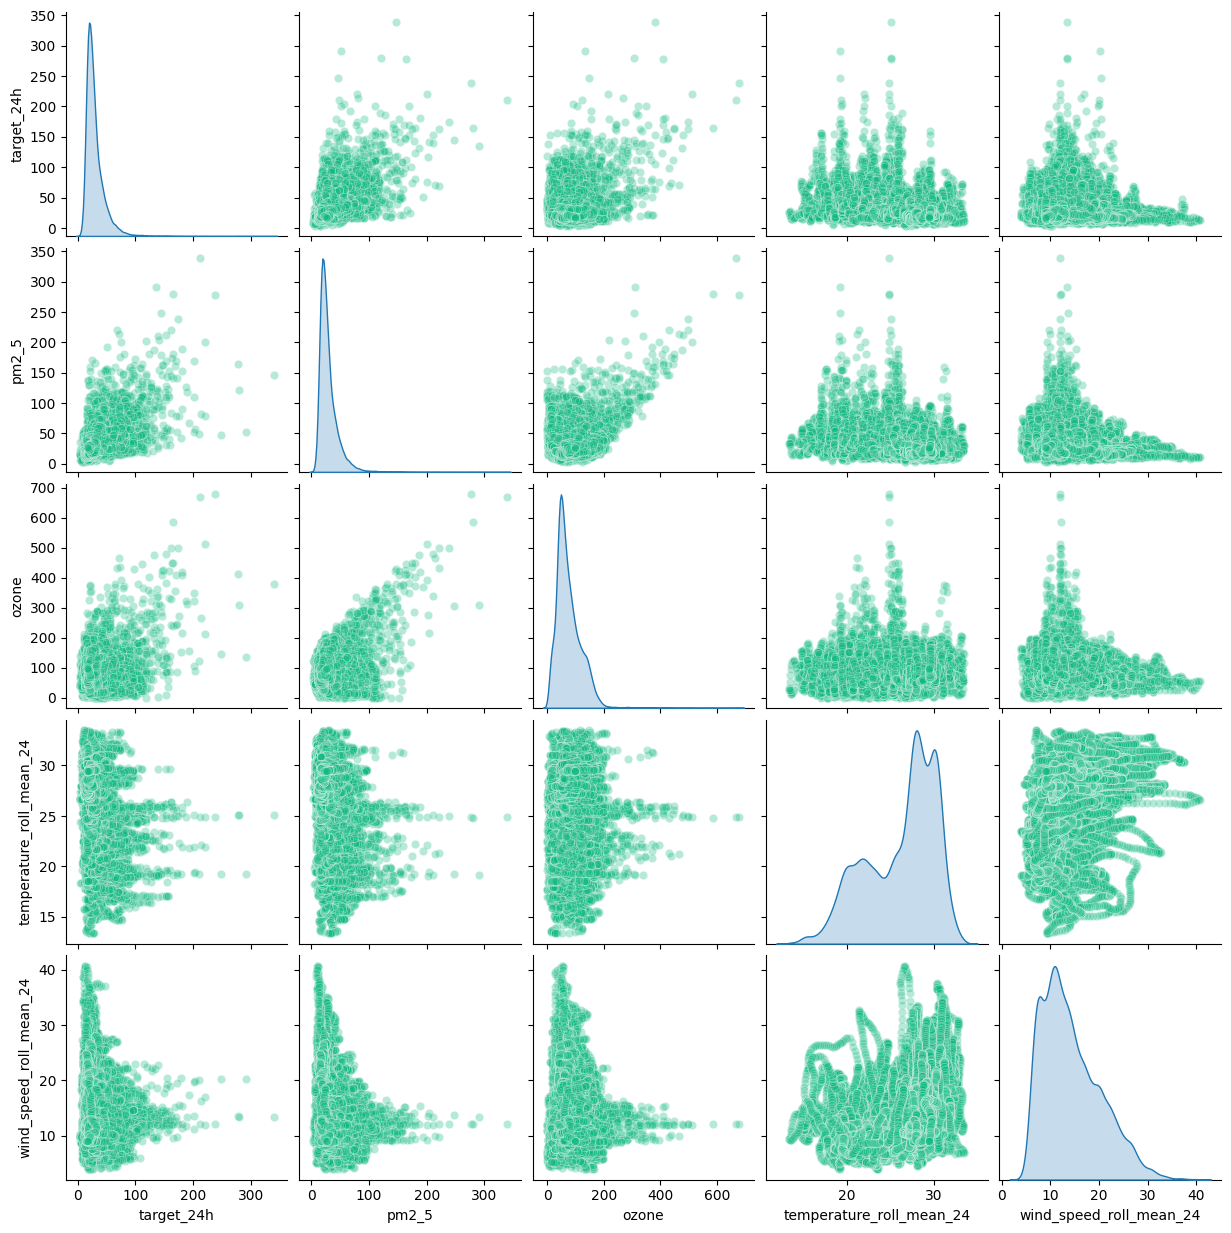

In [ ]:
# Compare top features vs target
features_to_compare = ['target_24h', 'pm2_5', 'ozone', 'temperature_roll_mean_24', 'wind_speed_roll_mean_24']

sns.pairplot(final_engineered_df[features_to_compare].dropna(),
             diag_kind='kde',
             plot_kws={'alpha': 0.3, 'color': '#10b981'})
plt.show()